# Input

In [10]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats, get_consensus_net

from ciim.src.clock.helper import clock_save_dir, predict_age, prepare_input
from ciim.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' 
tune_model = True
version = 'v1.0'
create_smoothed_data = False
temp_dir = f'{save_dir}/output/temp/'

cell_types = ['CD8T'] # ['CD4T','CD8T', 'MONO', 'B', 'NK']
n_cell_types = len(cell_types)

# Evaluate Wenchao's model

In [4]:
# - read the results of predictions
df_store = []
for dataset in ['C4', 'C5']:
    df = pd.read_csv(f'{base_dir}/clock/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
    df['dataset'] = 'data13_Korean' if dataset=='C4' else 'data12'
    df_store.append(df)
df = pd.concat(df_store, axis=0)

# - format 
df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type', 'donor_id': 'donor_age'}, inplace=True)
df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})

In [5]:
# - median prediction
median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')

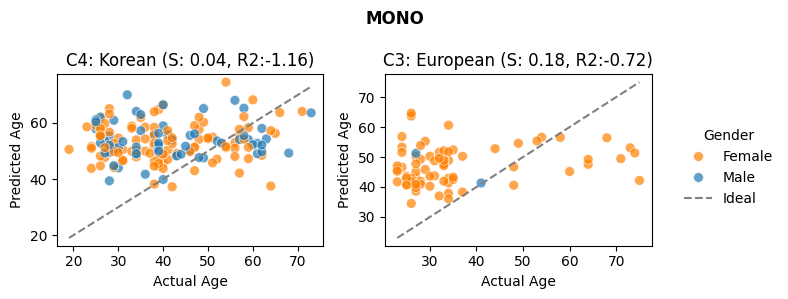

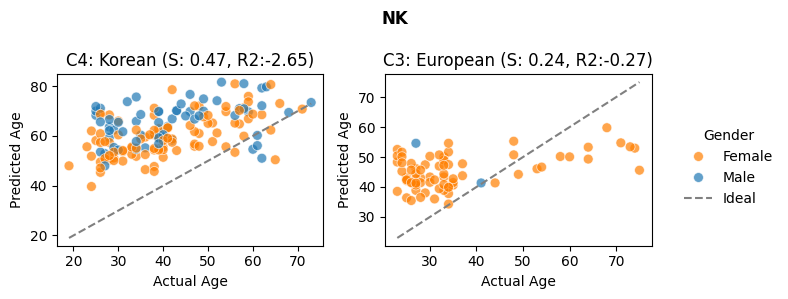

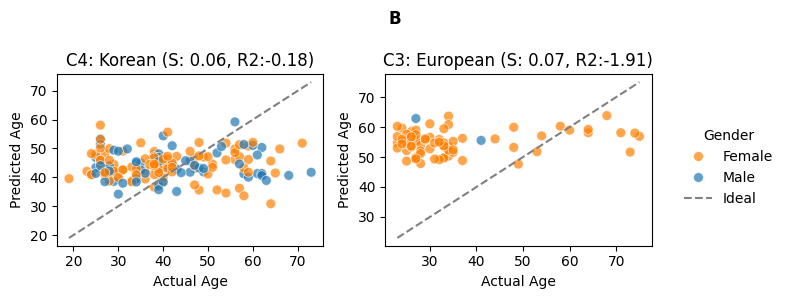

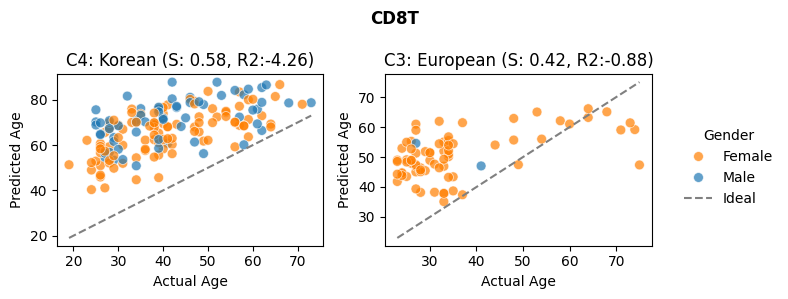

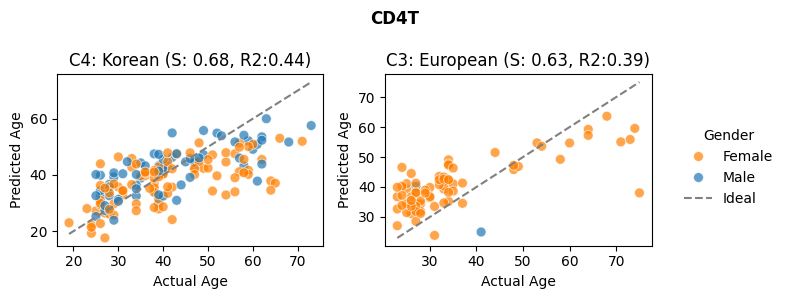

In [12]:
cell_types_local = median_prediction['cell_type'].unique()
datasets = median_prediction['dataset'].unique()

obs = median_prediction.copy()
for cell_type in cell_types_local:
        fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 3))
        i = 0
        for dataset in datasets:
            ax = axes[i] if len(datasets) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

            plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax)
            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')
        
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

# Calculate feature space using consensus GRNs -> smoothed

In [193]:
if create_smoothed_data:
    from ciim.src.clock.helper import prepare_input, predict_age
    for feature_type in ['gene_expression']:
        os.makedirs(f'{save_dir}/{feature_type}_smoothed/', exist_ok=True)
        for dataset in datasets_all+datasets_disease+datasets_drug_perturbation:
            for cell_type in cell_types:
                adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type='bulk')
                adata.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_bulk.h5ad')

# Train

In [13]:
from ciim.src.common import aging_clock_train_datasets
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *aging_clock_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]

    print("Running:", " ".join(cmd))

    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD8T --datasets_training data1 data7_allTPs_jalil SLE_European data13_Japanese data12 data13_Korean --feature_type gene_expression --data_type bulk --reg_type ridge --version v1.0 --temp_dir /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//output/temp/ --age_limit 20 --tune_model
{'cell_types': ['CD8T'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese', 'data12', 'data13_Korean'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'v1.0', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//output/temp/', 'age_limit': 20}


Traceback (most recent call last):
  File "/home/jnourisa/projs/ongoing/ciim/notebooks/../src/clock/script.py", line 30, in <module>
    os.makedirs(par['temp_dir'], exist_ok=True)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/os.py", line 215, in makedirs
    makedirs(head, exist_ok=exist_ok)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/os.py", line 215, in makedirs
    makedirs(head, exist_ok=exist_ok)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/os.py", line 215, in makedirs
    makedirs(head, exist_ok=exist_ok)
  [Previous line repeated 6 more times]
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/os.py", line 225, in makedirs
    mkdir(name, mode)
PermissionError: [Errno 13] Permission denied: '/Users'


CalledProcessError: Command '['python', '../src/clock/script.py', '--cell_types', 'CD8T', '--datasets_training', 'data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese', 'data12', 'data13_Korean', '--feature_type', 'gene_expression', '--data_type', 'bulk', '--reg_type', 'ridge', '--version', 'v1.0', '--temp_dir', '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//output/temp/', '--age_limit', '20', '--tune_model']' returned non-zero exit status 1.

# Run details

In [195]:
if reg_type == 'NN':
    loss = np.load('tmp/loss.npy')
    plt.plot(loss)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss over Epochs')
    plt.grid(True)
    plt.show()

In [196]:
if reg_type == 'NN':
    from ciim.src.clock.helper import evaluate_groupwise_median
    for cell_type in cell_types:
        adata_all = ad.read_h5ad(f"{temp_dir}{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        obs = adata_all.obs.copy()
        obs['sex'] = obs['sex'].astype(str)
        obs['donor_id'] = obs['donor_id'].astype(str)
        obs['age'] = obs['age'].astype(float)
        obs['predicted_age'] = obs['predicted_age'].astype(float)
        datasets = obs['dataset'].unique()
        fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 3))
        i = 0
        for dataset in datasets:
            ax = axes[i] if len(datasets) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age', 'sex'])['predicted_age'].median().reset_index()
            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")

            spearman = evaluate_groupwise_median(obs_d)['Spearman']
            ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')

        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

# Evaluation

In [197]:
force_write = True

In [198]:
evaluate_datasets = datasets_all + datasets_disease + datasets_drug_perturbation # 'data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean' , 'data13_Japanese', 
# evaluate_datasets = ['data13_Korean', 'data7_allTPs_jalil', 'SLE_European', 'Covid_50MHH', 'CXCL9']
prediction_file = f'{clock_save_dir}/prediction/{feature_type}_{data_type}_{reg_type}.csv'
if (force_write) or not os.path.exists(prediction_file):
    os.makedirs(f'{clock_save_dir}/prediction', exist_ok=True)
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition', 'Max_WHO_Group':'condition'}, inplace=True)
            if 'condition' not in adata.obs.columns:
                adata.obs['condition'] = 'healthy'
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type)
                obs = adata_c.obs[['age', 'predicted_age', 'sex', 'donor_id']].copy() 
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    obs.to_csv(prediction_file, index=False)
else:
    obs = pd.read_csv(prediction_file)
obs.head()

,age,predicted_age,sex,donor_id,dataset,cell_type,condition
1962,73,62.158815,Female,Data1_1000_1001,data1,CD8T,healthy
1963,57,59.095960,Female,Data1_1001_1002,data1,CD8T,healthy
1964,73,66.211545,Male,Data1_1002_1003,data1,CD8T,healthy
1965,58,57.668052,Female,Data1_1003_1004,data1,CD8T,healthy
1966,74,63.932422,Female,Data1_1004_1005,data1,CD8T,healthy


## Performance on train data

### Line plot

In [ ]:
from ciim.src.clock.helper import evaluate_groupwise_median
def plot_scatter_age_vs_predictedAge(df):
    sns.scatterplot(data=df, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
    min_age, max_age = df['age'].min(), df['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

    ax.set_xlabel("Actual Age")
    ax.set_ylabel("Predicted Age")
    rr = evaluate_groupwise_median(df)
    spearman = rr['Spearman']
    R2 = rr['R2']
    ax.set_title(f"{surrogate_names[dataset]} (S: {spearman:.2f}, R2:{R2:.2f})")

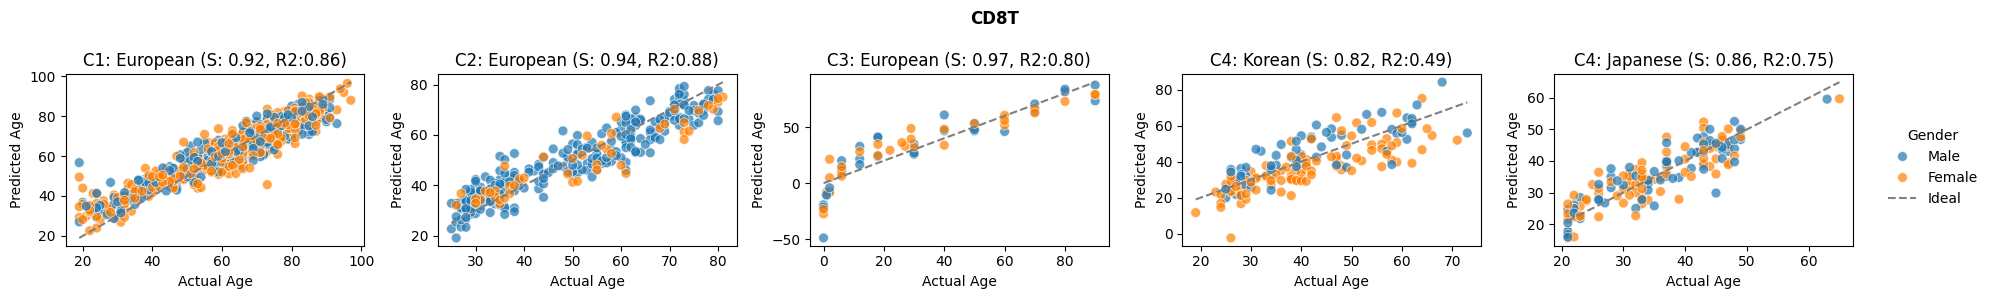

In [199]:
from ciim.src.clock.helper import evaluate_groupwise_median

obs['sex'] = obs['sex'].astype('str')

datasets_healthy = [d for d in  datasets_all if d in obs[(obs['condition'] == 'healthy')]['dataset'].unique()]



if True:
    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(datasets_healthy), figsize=(4*len(datasets_healthy), 3))
        i = 0
        for dataset in datasets_healthy:
            ax = axes[i] if len(datasets_healthy) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age', 'sex'])['predicted_age'].median().reset_index()
            plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax)

            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')
        
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

### Ridge

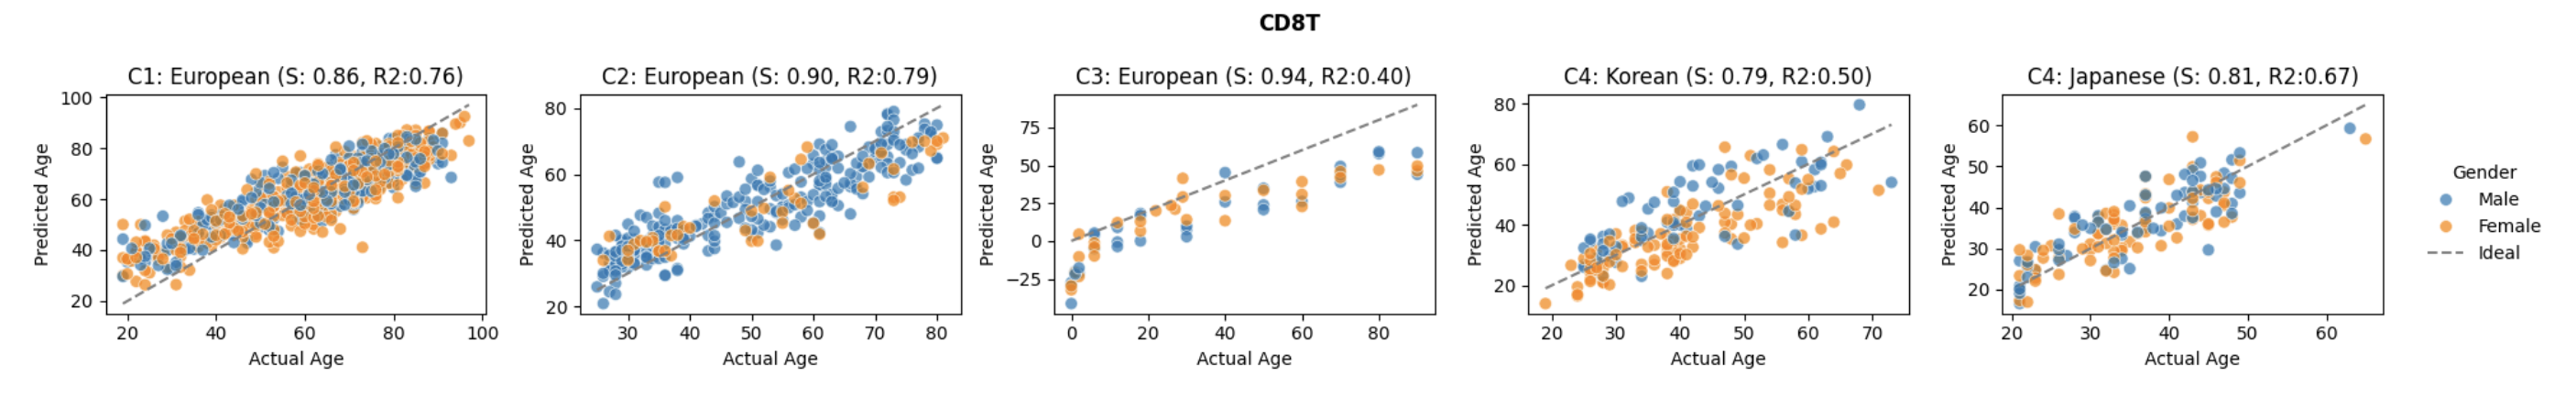

### Summary plot

In [200]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from ciim.src.clock.helper import evaluate_groupwise_median


datasets_healthy = ['data1', 'data7_allTPs_jalil', 'SLE_European' ,'data13_Japanese', 'data12', 'data13_Korean'] 
datasets_healthy = [d for d in datasets_healthy if d in obs['dataset'].unique()]

scores = []
for cell_type in cell_types:
    for dataset in datasets_healthy:
        df = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
        obs_d = df.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()

        rr = evaluate_groupwise_median(obs_d)
        spearman = rr['Spearman']
        r2 =  rr['R2']

        scores.append({
            'cell_type': cell_type,
            'dataset': dataset,
            'Spearman': spearman,
            'R2': r2
        })
scores_df = pd.DataFrame(scores)
scores_long = scores_df.melt(id_vars=['cell_type', 'dataset'], 
                              value_vars=['Spearman', 'R2'], 
                              var_name='metric', value_name='score')
scores_long['dataset'] = scores_long['dataset'].apply(lambda name: surrogate_names.get(name, name))
scores_long.head()

,cell_type,dataset,metric,score
0,CD8T,C1: European,Spearman,0.921037
1,CD8T,C2: European,Spearman,0.939023
2,CD8T,C5: European,Spearman,0.844612
3,CD8T,C4: Japanese,Spearman,0.861270
4,CD8T,C3: European,Spearman,0.965175


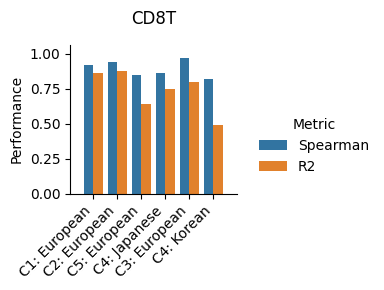

In [201]:
def multipanel_plot():
    fig, axes = plt.subplots(1, len(cell_types), figsize=(3*len(cell_types)+1, 3), sharey=True)
    for i, (cell_type) in enumerate(cell_types):
        ax = axes[i] if len(cell_types) > 1 else axes
        df_s = scores_long[scores_long['cell_type'] == cell_type]
        df_s['score'] = df_s['score'].clip(lower=0, upper=1) # clip the scores

        sns.barplot(
                ax=ax,
                data=df_s,
                x='dataset', y='score', hue='metric')
        ax.set_title(f"{cell_type}", pad=15)
        ax.set_ylabel("Performance")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(y=.1, x=.1)
    ax.legend(loc=(1.1, .1), title='Metric', frameon=False, fontsize=10)
    
    plt.tight_layout()
    
multipanel_plot()

#### ridge

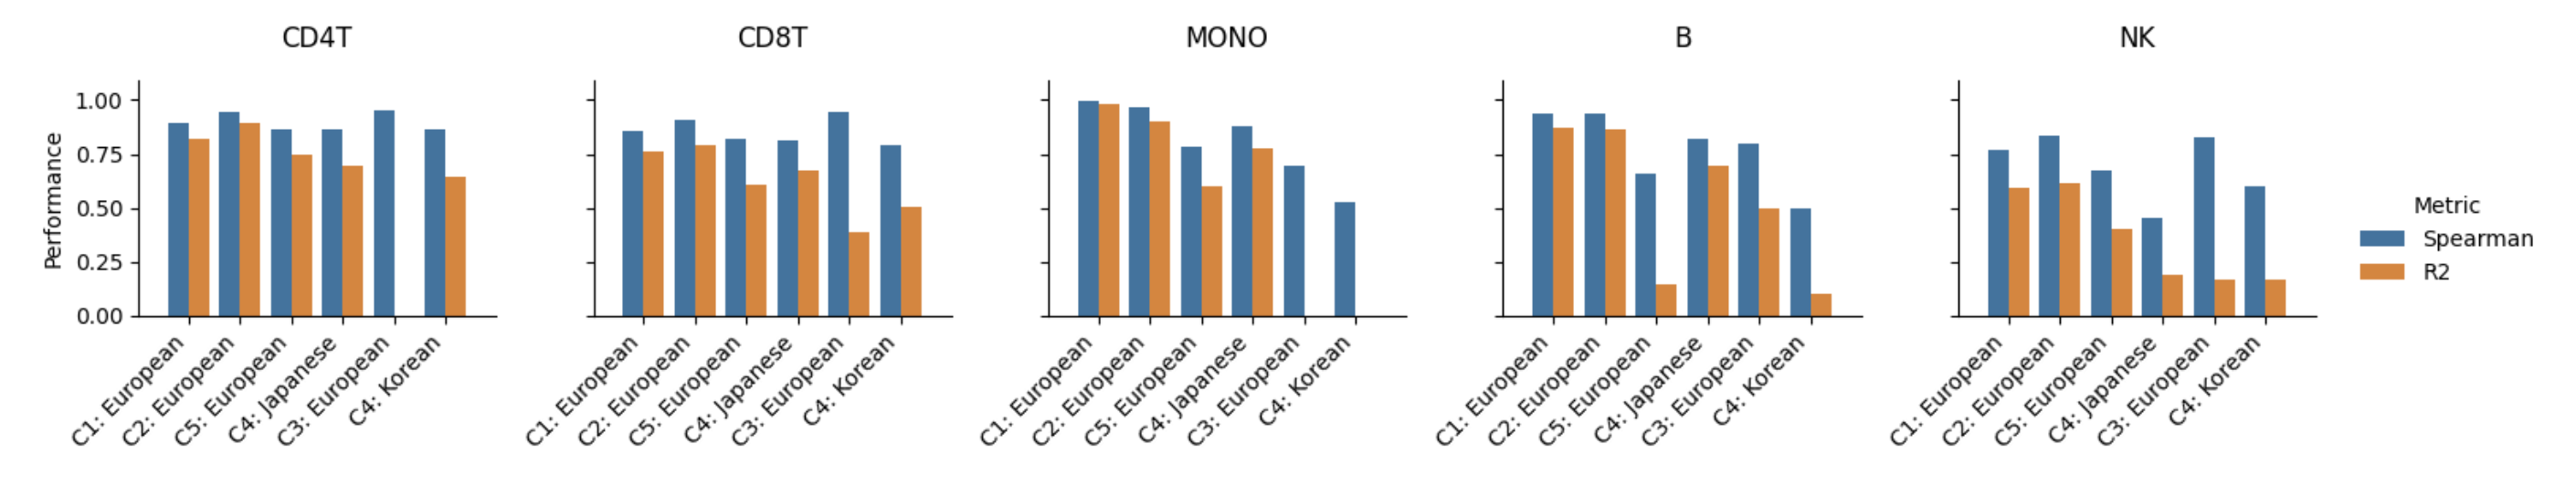

# Performance on disease

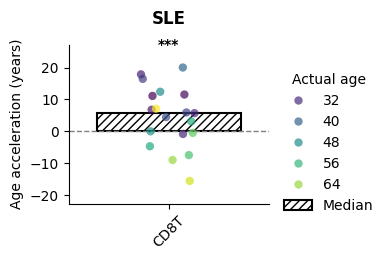

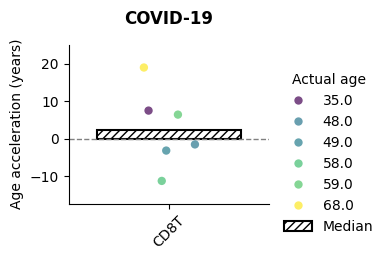

In [202]:
from ciim.src.clock.plots import wrapper_age_acceleration_disease, wrapper_age_acceleration_disease

# Call the function
wrapper_age_acceleration_disease(obs, disease_dataset='SLE_European')
wrapper_age_acceleration_disease(obs, disease_dataset='Covid_50MHH')

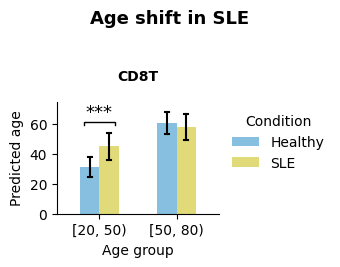

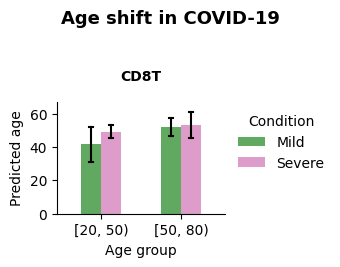

In [203]:
from ciim.src.clock.plots import wrapper_plot_age_acceleration_disease_bins

# Example usage (make sure n_cell_types, cell_types, and surrogate_names are defined)
wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='SLE_European')
wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='Covid_50MHH')

# Drug perturbation

In [204]:
obs_cxcl9 = obs[obs['dataset'] == 'CXCL9'].copy() 
obs_cxcl9['condition'].unique()

array(['0 h Unstimulated', '24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ'], dtype=object)

In [205]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin'),
                ('24 h LPS', '24 h LPS + ruxolitinib'),
                # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                ]
n_exp = len(experiments)

In [206]:
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = [] 
slopes = []

def test_paired(df_sub):
    df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age').dropna()
    t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
    slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
    return p_value, slope

def test_mixed_effect(df_sub):
    import statsmodels.formula.api as smf
    df_sub['condition'] = pd.Categorical(df_sub['condition'], categories=[ctr, treatment])
    # Fit the mixed effects model
    model = smf.mixedlm("predicted_age ~ condition", df_sub, groups=df_sub["donor_id"])
    result = model.fit()
    # # Summary of the model
    # print(result.summary())
    # Extract p-value and fixed effect estimate for treatment
    p_value = result.pvalues[f"condition[T.{treatment}]"]
    slope = result.params[f"condition[T.{treatment}]"]
    return p_value, slope
for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    for i, (ctr, treatment) in enumerate(experiments):
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub.shape[0] < 2:
            continue  # Skip if not enough data
        
        if 'bulk' in data_type:
            p_value, slope = test_paired(df_sub)

        elif data_type == 'metacell':
            df_sub = df_sub.groupby(['donor_id', 'condition'])['predicted_age'].median().reset_index()
            p_value, slope = test_paired(df_sub)
            # p_value, slope = test_mixed_effect(df_sub)
        else:
            raise ValueError("Unsupported data type")
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))

# Apply FDR correction
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Optionally: map corrected p-values back to plotting
pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

# Redraw plots with adjusted p-values
unique_donors = obs_cxcl9['donor_id'].unique()
donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))  # or use 'tab20', 'Set3', etc.


### All sig and not sig ones

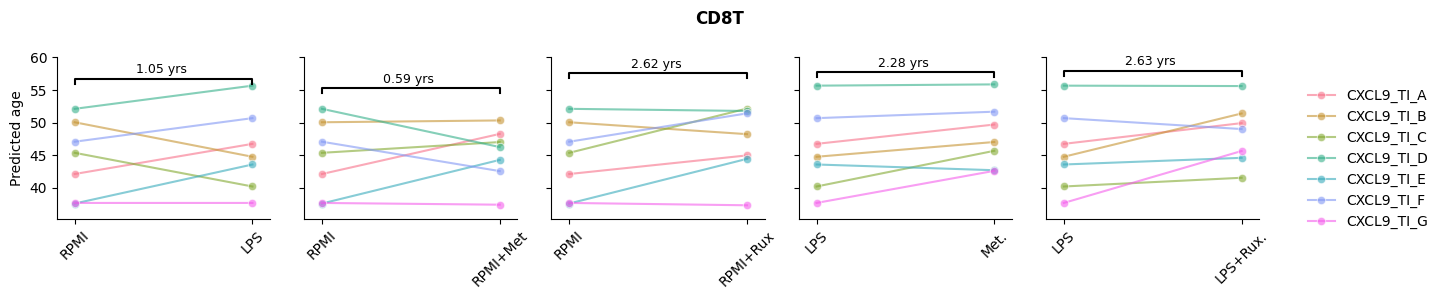

In [207]:
alpha = 0.05  # significance threshold

for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()
    fig, axes = plt.subplots(1, n_exp, figsize=(2.5 * n_exp + 2, 3), sharey=True)

    if n_exp == 1:
        axes = [axes]

    for i, (ctr, treatment) in enumerate(experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')
        unique_donors = df_pivot.index.unique()
        donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

        available_conditions = [cond for cond in [ctr, treatment] if cond in df_pivot.columns]
        if len(available_conditions) < 2:
            continue  # Skip if not both conditions are present

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_id',
            value_vars=available_conditions,
            var_name='condition',
            value_name='predicted_age'
        )

        df_plot['condition'] = df_plot['condition'].apply(lambda name: pretty_names.get(name, name))
        sns.lineplot(
            data=df_plot, x='condition', y='predicted_age',
            hue='donor_id', marker='o', alpha=0.6, ax=ax,
            legend=True, palette=donor_palette
        )

        # Bracket annotation
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        
        xticks = list(ax.get_xticks())
        x1, x2 = xticks[0], xticks[1]

        group_stats = df_plot.groupby('condition')['predicted_age'].agg(['mean', 'std'])
        cond1, cond2 = df_plot['condition'].unique()
        y1 = group_stats.loc[cond1, 'mean'] + group_stats.loc[cond1, 'std']
        y2 = group_stats.loc[cond2, 'mean'] + group_stats.loc[cond2, 'std']
        y_bracket = max(y1, y2) + 5

        h = 0.8  # height of bracket
        ax.plot([x1, x1, x2, x2], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
                lw=1.5, c='black')
        
        ax.text((x1 + x2) / 2, y_bracket + 0.4, f"{slope:.2f} yrs {star}",
                ha='center', va='bottom', fontsize=9)

        ax.set_title("")  # No text in title
        ax.set_ylabel("Predicted age")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.1)
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

### Only sig ones

In [208]:
alpha = 0.05  # significance threshold

for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < alpha
    ]
    if not significant_experiments:
        continue

    fig, axes = plt.subplots(1, len(significant_experiments), figsize=(2 * len(significant_experiments) + 1, 2.7), sharey=True)
    if len(significant_experiments) == 1:
        axes = [axes]

    for i, (ctr, treatment) in enumerate(significant_experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')
        df_pivot['donor_id'] = ['Donor ' + str(i+1) for i, d in enumerate(df_pivot.index)]
        df_pivot.set_index('donor_id', inplace=True)
        df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

        unique_donors = df_pivot.index.unique()
        donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_id', 
            value_vars=[ctr, treatment], 
            var_name='condition', 
            value_name='predicted_age'
        )
        df_plot['condition'] = df_plot['condition'].map(pretty_names)

        sns.lineplot(
            data=df_plot,
            x='condition', y='predicted_age',
            hue='donor_id', marker='o', alpha=0.6,
            ax=ax, palette=donor_palette, legend=True
        )

        # Get p-value and slope
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

        # Draw significance bracket
        y_max = df_plot['predicted_age'].max()
        h = 1  # height of bracket
        y_bracket = y_max + 7

        ax.plot([0, 0, 1, 1], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
                lw=1.5, c='black')
        ax.text(0.5, y_bracket + 1, f"{slope:.2f} yrs {star}", ha='center', va='bottom', fontsize=10)

        ax.set_title("")  # No text in title
        ax.set_xlabel("")
        ax.set_ylabel("Predicted Age")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.2)
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)
    fig.suptitle(f'Age shift in drug perturbation ({cell_type})', fontsize=12, weight='bold')
    fig.tight_layout()
    # plt.show()